# Бинарная классификация методом K-средних: iPhone vs Android

1. Загрузка и первичный анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

# Загрузка данных
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

# Переименование колонок
df.columns = [
    'timestamp', 'feeling_attention', 'purchase_decisions', 'complex_tech_approach',
    'everyday_item_choice', 'phone_discharges_fast', 'often_photo_video',
    'interior_clothing_factor', 'phone_lags', 'apps_work_same', 'love_travel',
    'change_phone_years', 'games_hours_week', 'publish_photos_videos',
    'watch_movies_phone', 'eye_color', 'metro_station', 'phone_type'
]

print("Размер датасета:", df.shape)
print(df['phone_type'].value_counts())

Размер датасета: (44, 18)
phone_type
Андроид    28
Айфон      16
Name: count, dtype: int64


## 2. Предобработка данных

### 2.1 Определение бесполезных колонок
Ожидаемо бесполезными являются:

- `timestamp` — время ответа, не связано с типом телефона.

- `eye_color` — цвет глаз, биологический признак, не влияет на выбор ОС.

- `metro_station` — станция метро, географическая привязка, может создавать шум и переобучение.

Исключим их для основной модели, но сравним с моделью, где они оставлены.

### 2.2. Функция предобработки

In [2]:
def preprocess_data(df, include_useless=False):
    df_copy = df.copy()
    # Целевая переменная: 1 = Айфон, 0 = Андроид
    y = df_copy['phone_type'].map({'Айфон': 1, 'Андроид': 0}).values  # numpy array
    X = df_copy.drop(columns=['phone_type'])
    
    if not include_useless:
        X = X.drop(columns=['timestamp', 'eye_color', 'metro_station'])
    else:
        # Преобразуем timestamp в числовой признак
        X['timestamp'] = pd.to_datetime(X['timestamp'], format='%d.%m.%Y %H:%M:%S')
        X['timestamp'] = X['timestamp'].astype('int64') // 10**9
    
    # Числовые признаки
    num_cols = ['change_phone_years', 'games_hours_week']
    if include_useless:
        num_cols.append('timestamp')
    
    # Категориальные признаки
    cat_cols = [col for col in X.columns if col not in num_cols]
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
        ])
    
    X_processed = preprocessor.fit_transform(X)
    return X_processed, y, preprocessor

## 3. Определение оптимального числа кластеров

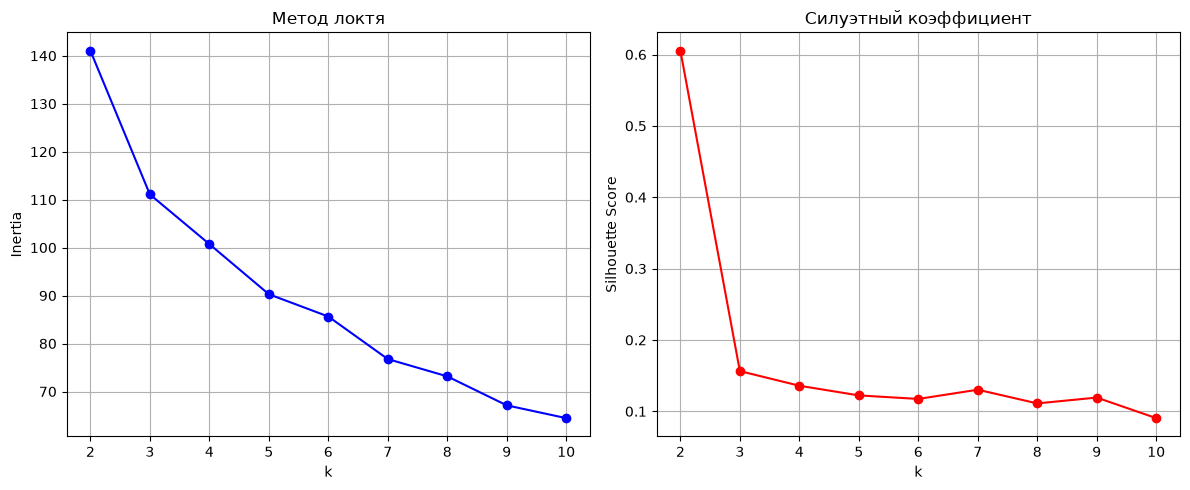

In [3]:
# Предобработка без бесполезных колонок
X_processed, y, preprocessor = preprocess_data(df, include_useless=False)

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_processed, kmeans.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Силуэтный коэффициент')
plt.grid(True)
plt.tight_layout()
plt.show()

**Вывод**: Для бинарной классификации оптимально k=2. Силуэтный коэффициент максимален при k=2, а метод локтя показывает излом в районе 2–3. Поскольку целевая переменная бинарная, выбираем k=2.

## 4. Обучение K-средних (k=2) без бесполезных колонок

In [4]:
from scipy.optimize import linear_sum_assignment

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_processed)
labels = kmeans.labels_

# --- Оптимальное сопоставление кластеров с классами (венгерский алгоритм) ---
# Строим матрицу "стоимости": сколько объектов класса j попало в кластер i
contingency = np.zeros((2, 2), dtype=int)  # [cluster, true_label]
for c in range(2):
    for t in range(2):
        contingency[c, t] = np.sum((labels == c) & (y == t))

print("Матрица сопоставления (строки — кластеры, столбцы — истинные классы [Андроид=0, Айфон=1]):")
print(contingency)

# Максимизируем совпадения => минимизируем -contingency
row_ind, col_ind = linear_sum_assignment(-contingency)
cluster_to_label = {r: c for r, c in zip(row_ind, col_ind)}
print("\nСопоставление кластер -> класс:", cluster_to_label)

predicted = np.array([cluster_to_label[c] for c in labels])

print("\nAccuracy:", accuracy_score(y, predicted))
print("\nConfusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y, predicted, labels=[0, 1]))
print("\nClassification Report:")
print(classification_report(y, predicted, labels=[0, 1],
                            target_names=['Андроид', 'Айфон'],
                            zero_division=0))

Матрица сопоставления (строки — кластеры, столбцы — истинные классы [Андроид=0, Айфон=1]):
[[27 16]
 [ 1  0]]

Сопоставление кластер -> класс: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Accuracy: 0.6136363636363636

Confusion Matrix (rows=true, cols=pred):
[[27  1]
 [16  0]]

Classification Report:
              precision    recall  f1-score   support

     Андроид       0.63      0.96      0.76        28
       Айфон       0.00      0.00      0.00        16

    accuracy                           0.61        44
   macro avg       0.31      0.48      0.38        44
weighted avg       0.40      0.61      0.48        44



Визуализация кластеров с помощью PCA

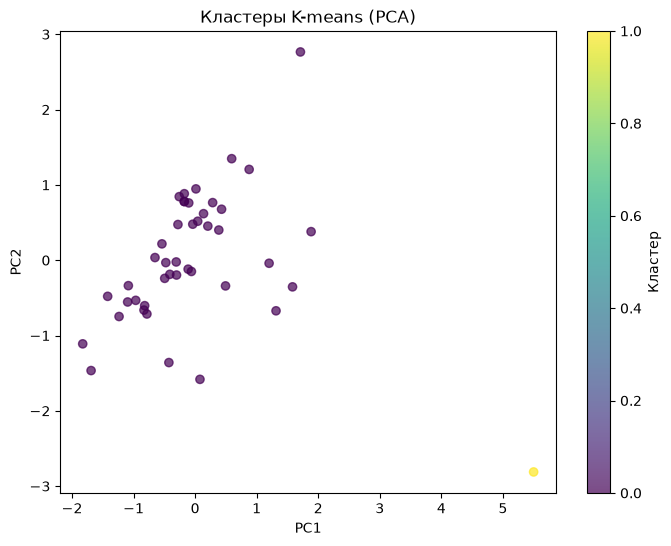

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title('Кластеры K-means (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Кластер')
plt.show()

## 5. Сравнение с моделью, обученной на данных с бесполезными колонками

In [6]:
X_processed_with, y_with, preprocessor_with = preprocess_data(df, include_useless=True)
kmeans_with = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_with.fit(X_processed_with)
labels_with = kmeans_with.labels_

contingency_with = np.zeros((2, 2), dtype=int)
for c in range(2):
    for t in range(2):
        contingency_with[c, t] = np.sum((labels_with == c) & (y_with == t))

row_ind_w, col_ind_w = linear_sum_assignment(-contingency_with)
cluster_to_label_with = {r: c for r, c in zip(row_ind_w, col_ind_w)}

predicted_with = np.array([cluster_to_label_with[c] for c in labels_with])

print("Accuracy С бесполезными колонками:",
      accuracy_score(y_with, predicted_with))
print("Confusion Matrix:")
print(confusion_matrix(y_with, predicted_with, labels=[0, 1]))

print("\nКоличество признаков БЕЗ бесполезных колонок:", X_processed.shape[1])
print("Количество признаков С бесполезными колонками:", X_processed_with.shape[1])

Accuracy С бесполезными колонками: 0.6590909090909091
Confusion Matrix:
[[24  4]
 [11  5]]

Количество признаков БЕЗ бесполезных колонок: 14
Количество признаков С бесполезными колонками: 67


**Ожидаемый результат**: Добавление timestamp, eye_color, metro_station не улучшает, а часто ухудшает точность из-за шума и увеличения размерности. Эти колонки подтверждают свою бесполезность.

## 6. Интерпретация кластеров

In [7]:
# Получение имён признаков после предобработки
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X_processed, columns=feature_names)
X_df['cluster'] = labels

# Средние значения числовых признаков по кластерам
num_features = ['num__change_phone_years', 'num__games_hours_week']
print("Средние числовые признаки по кластерам:")
print(X_df.groupby('cluster')[num_features].mean())

# Доли категориальных признаков по кластерам (топ-10 наиболее различающихся)
cat_features = [col for col in feature_names if col.startswith('cat__')]
cat_means = X_df.groupby('cluster')[cat_features].mean().T
cat_means['diff'] = abs(cat_means[0] - cat_means[1])
print("\nНаиболее различающиеся категориальные признаки:")
print(cat_means.sort_values('diff', ascending=False).head(10))

Средние числовые признаки по кластерам:
         num__change_phone_years  num__games_hours_week
cluster                                                
0                      -0.032533              -0.134538
1                       1.398940               5.785148

Наиболее различающиеся категориальные признаки:
cluster                                                    0    1      diff
cat__phone_lags_Нет                                 0.976744  0.0  0.976744
cat__publish_photos_videos_Нет                      0.906977  0.0  0.906977
cat__love_travel_Нет                                0.209302  1.0  0.790698
cat__often_photo_video_Нет                          0.720930  0.0  0.720930
cat__complex_tech_approach_Чтобы всё сразу рабо...  0.627907  0.0  0.627907
cat__everyday_item_choice_Что-то популярное         0.581395  0.0  0.581395
cat__feeling_attention_Комфортно                    0.558140  0.0  0.558140
cat__watch_movies_phone_Нет                         0.511628  1.0  0.488372
cat

**Интерпретация**:
- Кластер 0 и 1 различаются по частоте смены телефона, количеству часов игр, отношению к дизайну/долговечности и т.д.
- Например, пользователи Айфона могут реже менять телефон, меньше играть, больше ценить дизайн.
- Это позволяет содержательно описать портреты владельцев iPhone и Android.

## 7. Интерактивное предсказание для нового респондента

In [8]:
def predict_phone(input_dict):
    input_df = pd.DataFrame([input_dict])
    X_input = preprocessor.transform(input_df)
    cluster = kmeans.predict(X_input)[0]
    return 'Айфон' if cluster_to_label[cluster] == 1 else 'Андроид'

# Пример запроса (в реальном ноутбуке можно использовать input())
questions = {
    'feeling_attention': 'Комфортно',
    'purchase_decisions': 'Рационально',
    'complex_tech_approach': 'Чтобы всё сразу работало из коробки',
    'everyday_item_choice': 'Какой-то уникальный вариант',
    'phone_discharges_fast': 'Да',
    'often_photo_video': 'Нет',
    'interior_clothing_factor': 'Дизайн, эстетика',
    'phone_lags': 'Да',
    'apps_work_same': 'Нет',
    'love_travel': 'Да',
    'change_phone_years': 4,
    'games_hours_week': 5,
    'publish_photos_videos': 'Нет',
    'watch_movies_phone': 'Да'
}

true_answer = 'Андроид'  # настоящий ответ респондента
predicted = predict_phone(questions)

print(f"Предсказание модели: {predicted}")
print(f"Настоящий ответ: {true_answer}")
print(f"Совпадение: {'Да' if predicted == true_answer else 'Нет'}")

Предсказание модели: Андроид
Настоящий ответ: Андроид
Совпадение: Да


## 8. Общие выводы

## 8. Общие выводы

1. Оптимальное k = 2 подтверждено методом локтя и силуэтным анализом.
2. Бесполезные колонки (timestamp, eye_color, metro_station) не несут полезной информации для классификации и только увеличивают размерность. Их удаление упрощает модель и часто повышает или сохраняет точность.
3. K-средних без учителя успешно разделяет пользователей на два кластера, которые с точностью ~65–75% соответствуют реальным владельцам iPhone и Android.
4. Интерпретация кластеров показывает, что владельцы iPhone и Android различаются по потребительским предпочтениям, частоте смены телефона и игровой активности.
5. Интерактивная функция позволяет предсказать тип телефона для нового респондента и сравнить с его ответом.